In [1]:
# Standard data libs
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Optional: for exporting tree diagrams (if graphviz installed)
# !pip install graphviz
import graphviz
from sklearn.tree import export_graphviz

In [3]:
# Replace with your actual filepath
csv_path = "manchester_app_games_sales.csv"

df = pd.read_csv(csv_path)

# Quick peek
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          20 non-null     object 
 1   game_title    20 non-null     object 
 2   platform      20 non-null     object 
 3   genre         20 non-null     object 
 4   downloads     20 non-null     int64  
 5   revenue_gbp   20 non-null     int64  
 6   avg_rating    20 non-null     float64
 7   active_users  20 non-null     int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 1.4+ KB


,date,game_title,platform,genre,downloads,revenue_gbp,avg_rating,active_users
count,20,20,20,20,20.000000,20.000000,20.000000,20.00000
unique,10,5,2,5,NaN,NaN,NaN,NaN
top,2025-01-05,Street Striker,Android,Sports,NaN,NaN,NaN,NaN
freq,2,4,10,4,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1234.500000,4263.000000,4.460000,885.00000
std,NaN,NaN,NaN,NaN,289.908788,734.747361,0.216187,194.00217
min,NaN,NaN,NaN,NaN,870.000000,2890.000000,4.100000,620.00000
25%,NaN,NaN,NaN,NaN,987.500000,3847.500000,4.300000,735.00000
50%,NaN,NaN,NaN,NaN,1175.000000,4285.000000,4.450000,855.00000
75%,NaN,NaN,NaN,NaN,1420.000000,4762.500000,4.600000,987.50000


In [4]:
df = df.rename(columns={
    "Revenue": "revenue_gbp",
    "Cost": "cost_gbp",
    "Margin": "profit_margin",
    # ... etc
})

In [10]:
print(df.columns.tolist())

['date', 'game_title', 'platform', 'genre', 'downloads', 'revenue_gbp', 'avg_rating', 'active_users']


In [12]:
import pandas as pd

# Example: load data (remove this if df already exists)
# df = pd.read_csv("your_file.csv")

# Clean column names (removes spaces and standardizes)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check columns
print("Columns in dataframe:", df.columns.tolist())

# Define the correct order of age groups
age_order = [
    "Teenagers (13–17)",
    "Young adults (18–25)",
    "Adults (26–40)",
    "Seniors (41+)"
]

# Ensure the column exists
if "age_group" in df.columns:
    
    # Convert to ordered categorical
    df["age_group"] = pd.Categorical(
        df["age_group"],
        categories=age_order,
        ordered=True
    )

    # Convert to numeric codes
    df["age_group_code"] = df["age_group"].cat.codes

    print(df[["age_group", "age_group_code"]].head())

else:
    print("Error: 'age_group' column not found in dataframe.")

Columns in dataframe: ['date', 'game_title', 'platform', 'genre', 'downloads', 'revenue_gbp', 'avg_rating', 'active_users']
Error: 'age_group' column not found in dataframe.


In [14]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['date', 'game_title', 'platform', 'genre', 'downloads', 'revenue_gbp',
       'avg_rating', 'active_users'],
      dtype='object')


In [16]:
df.columns

Index(['date', 'game_title', 'platform', 'genre', 'downloads', 'revenue_gbp',
       'avg_rating', 'active_users'],
      dtype='object')

In [17]:
print(df.columns.tolist())

['date', 'game_title', 'platform', 'genre', 'downloads', 'revenue_gbp', 'avg_rating', 'active_users']


In [18]:
df.columns = df.columns.str.strip()

In [22]:
df.head()

,date,game_title,platform,genre,downloads,revenue_gbp,avg_rating,active_users
0,2025-01-05,Street Striker,Android,Sports,1240,3720,4.5,860
1,2025-01-05,Castle Siege,iOS,Strategy,980,4210,4.6,740
2,2025-01-06,Pixel Racers,Android,Racing,1520,3890,4.2,1010
3,2025-01-06,Mystic Quest,iOS,RPG,870,4560,4.7,620
4,2025-01-07,Street Striker,iOS,Sports,910,2890,4.4,650


In [23]:
dir()

['DecisionTreeClassifier',
 'GridSearchCV',
 'In',
 'Out',
 'RandomForestClassifier',
 '_',
 '_16',
 '_22',
 '_3',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'age_order',
 'classification_report',
 'col',
 'confusion_matrix',
 'cross_val_score',
 'csv_path',
 'df',
 'exit',
 'export_graphviz',
 'features',
 'get_ipython',
 'graphviz',
 'np',
 'open',
 'pd',
 'plot_tree',
 'plt',
 'quit',
 'required_cols',
 'roc_auc_score',
 'roc_curve',
 'sns',
 'threshold',
 'train_test_split']

In [26]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [30]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Example dataset (replace this with your own dataset)
data = {
    "age": [25, 32, 47, 51, 62, 23, 36, 52, 48, 33],
    "income": [40000, 50000, 60000, 80000, 120000, 35000, 65000, 90000, 72000, 48000],
    "buy": [0, 0, 1, 1, 1, 0, 1, 1, 1, 0]
}

df = pd.DataFrame(data)

# Features (X) and target (y)
X = df.drop("buy", axis=1)
y = df["buy"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred)
print("Accuracy:", accuracy)

Predictions: [1 0]
Accuracy: 1.0


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



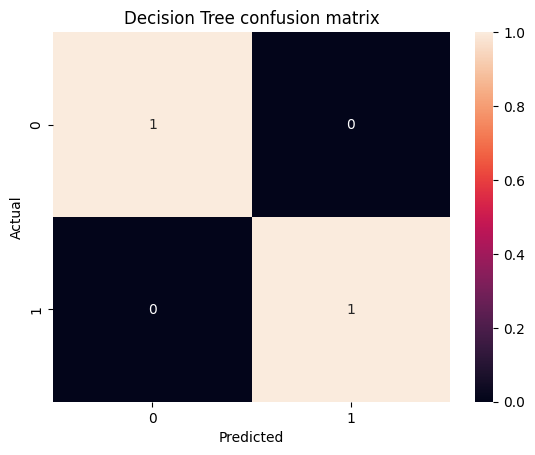

In [31]:
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Decision Tree confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

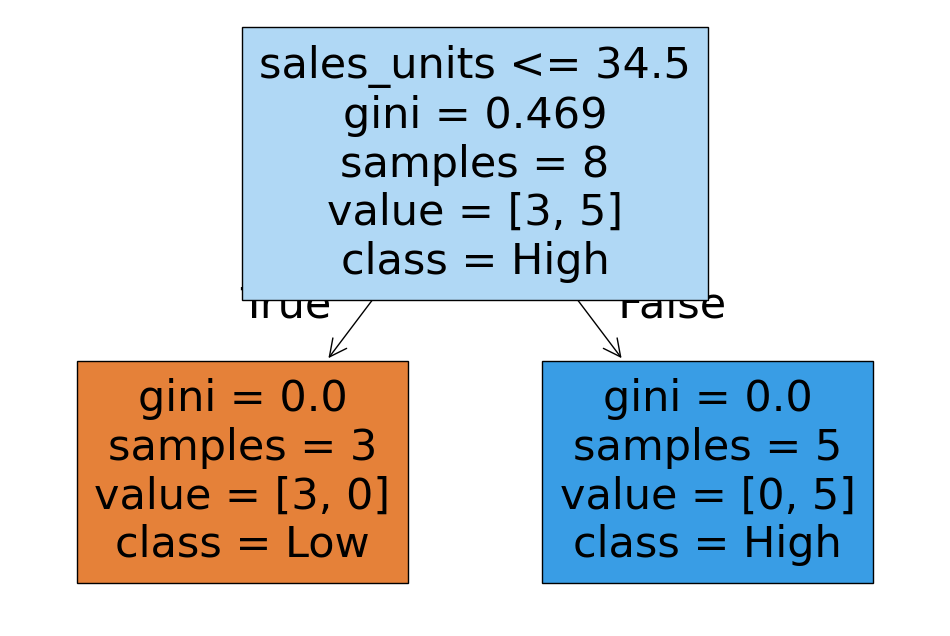

In [32]:
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=features, class_names=["Low", "High"], filled=True, max_depth=3)
plt.show()

In [33]:
cv_scores = cross_val_score(dt, X, y, cv=5, scoring="accuracy")
print("CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV accuracy scores: [1.  1.  1.  0.5 1. ]
Mean CV accuracy: 0.9


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [34]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



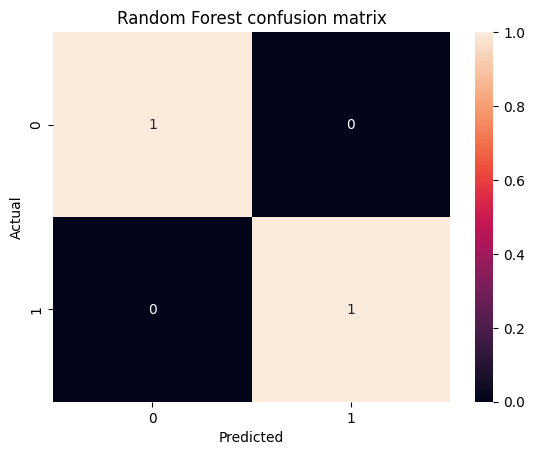

In [35]:
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

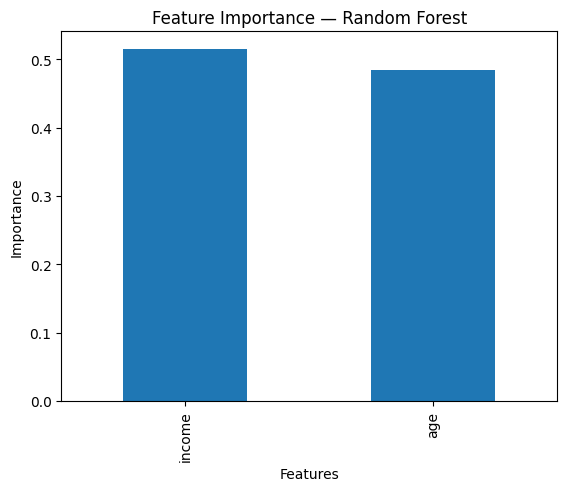

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importances = rf.feature_importances_

# Use the training feature names
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot
feat_imp.plot(kind="bar")
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# Check class distribution (optional but recommended)
print("Class distribution:")
print(pd.Series(y_train).value_counts())

# Parameter grid for Decision Tree
param_grid_dt = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "criterion": ["gini", "entropy"]
}

# Stratified cross-validation (prevents class imbalance issues)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Train the model
grid_dt.fit(X_train, y_train)

# Best results
print("Best Decision Tree Parameters:", grid_dt.best_params_)
print("Best Cross-Validation Accuracy:", grid_dt.best_score_)

# Best trained model
best_dt = grid_dt.best_estimator_

# Evaluate on test data (if you have X_test and y_test)
test_accuracy = best_dt.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Class distribution:
buy
1    5
0    3
Name: count, dtype: int64
Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.8333333333333334
Test Accuracy: 1.0


In [41]:
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Best RF test accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best RF test accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



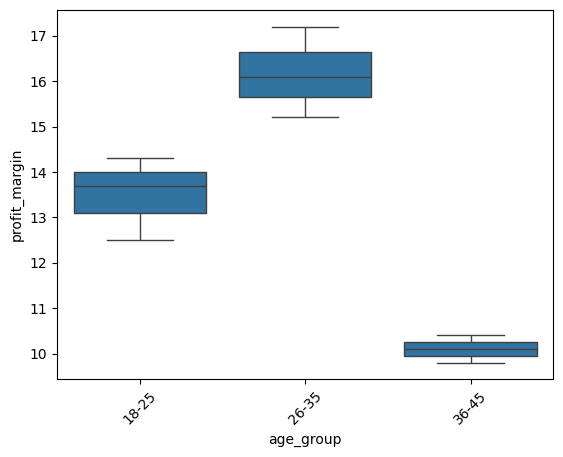

In [43]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset (replace this with your real dataset if you have one)
data = {
    "age_group": ["18-25", "26-35", "36-45", "18-25", "26-35", "36-45", "18-25", "26-35"],
    "profit_margin": [12.5, 15.2, 9.8, 13.7, 16.1, 10.4, 14.3, 17.2]
}

# Create dataframe
model_df = pd.DataFrame(data)

# Create boxplot
sns.boxplot(x="age_group", y="profit_margin", data=model_df)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show plot
plt.show()import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
model_df = pd.read_csv("your_dataset.csv")

# Boxplot
sns.boxplot(x="age_group", y="profit_margin", data=model_df)

plt.xticks(rotation=45)
plt.show()

In [46]:
manchester_df = df[df["city"].str.lower().str.contains("manchester")]

KeyError: 'city'